# AutoEncoder on Correlation Matrices
In this notebook we train an AutoEncoder (with non-linear activations) on full correlation matrices, compress them into a latent space, reconstruct them, and evaluate reconstruction quality across different latent dimensions.

In [1]:
from pathlib import Path
import random
import warnings
import sys
import json

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

## Step 1: Load Train/Val/Test Splits
Load correlation matrices from an existing dataset folder containing `train.pt`, `val.pt`, and `test.pt`.
- Local PC: `data/processed/dataset/<DATASET_NAME>`
- Google Colab: `dataset_tesi/<DATASET_NAME>`

In [2]:
DATASET_NAME = 'data_00_20_w724_s10'

if 'google.colab' in sys.modules:
    print('Ambiente rilevato: Google Colab')
    IS_COLAB = True
else:
    print('Ambiente rilevato: Locale (PC)')
    IS_COLAB = False

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    base_dir = Path('/content/drive/MyDrive/dataset_tesi')
else:
    project_root = Path.cwd().resolve().parent
    base_dir = project_root / 'data' / 'processed' / 'dataset'

dataset_dir = base_dir / DATASET_NAME

TRAIN_FILE = dataset_dir / 'train.pt'
VAL_FILE = dataset_dir / 'val.pt'
TEST_FILE = dataset_dir / 'test.pt'

for split_path in (TRAIN_FILE, VAL_FILE, TEST_FILE):
    if not split_path.exists():
        raise FileNotFoundError(
            f"Errore: Il file '{split_path.name}' non e stato trovato in: {dataset_dir.absolute()}"
        )

print(f'Dataset selezionato: {DATASET_NAME}')
print(f'Train: {TRAIN_FILE.name} | Val: {VAL_FILE.name} | Test: {TEST_FILE.name}')

Ambiente rilevato: Locale (PC)
Dataset selezionato: data_00_20_w724_s10
Train: train.pt | Val: val.pt | Test: test.pt


In [3]:
def load_corr_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        meta = {k: v for k, v in payload.items() if k != 'corr_tensor'}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')

    return corr_tensor.float(), meta


train_corr, train_meta = load_corr_payload(TRAIN_FILE)
val_corr, val_meta = load_corr_payload(VAL_FILE)
test_corr, test_meta = load_corr_payload(TEST_FILE)

if train_corr.shape[1:] != test_corr.shape[1:]:
    raise ValueError(f'Train/test asset dims mismatch: {train_corr.shape} vs {test_corr.shape}')
if val_corr.shape[1:] != train_corr.shape[1:]:
    raise ValueError(f'Val/train asset dims mismatch: {val_corr.shape} vs {train_corr.shape}')

print(f'train_corr shape: {tuple(train_corr.shape)}')
print(f'val_corr shape:   {tuple(val_corr.shape)}')
print(f'test_corr shape:  {tuple(test_corr.shape)}')

train_corr shape: (289, 362, 362)
val_corr shape:   (82, 362, 362)
test_corr shape:  (41, 362, 362)


## Step 2: Cholesky Decomposition + Vectorization
Convert each correlation matrix to its lower-triangular Cholesky factor $L$ (with a small diagonal jitter if needed).
Train/val/test are then represented by the lower-triangular entries of $L$ (including the diagonal).

In [4]:
def cholesky_with_jitter(mats: torch.Tensor, jitter: float = 1e-6, max_tries: int = 5):
    if mats.ndim != 3 or mats.shape[1] != mats.shape[2]:
        raise ValueError(f'Invalid shape for cholesky input: {mats.shape}')
    
    n, d, _ = mats.shape
    Ls = torch.zeros_like(mats)
    jitter_used = torch.zeros(n)
    eye = torch.eye(d)
    
    for i in range(n):
        mat = mats[i]
        success = False
        for k in range(max_tries):
            eps = jitter * (10 ** k)
            try:
                Ls[i] = torch.linalg.cholesky(mat + eps * eye)
                jitter_used[i] = eps
                success = True
                break
            except RuntimeError:
                continue
        if not success:
            raise RuntimeError(
                f'Cholesky failed for matrix index {i} even with jitter up to {eps:.2e}'
            )
    
    return Ls, jitter_used


train_L, train_jitter = cholesky_with_jitter(train_corr)
val_L, val_jitter = cholesky_with_jitter(val_corr)
test_L, test_jitter = cholesky_with_jitter(test_corr)

# Keep copies of original correlations for optional evaluation
train_corr_np = train_corr.numpy().astype(np.float32)
val_corr_np = val_corr.numpy().astype(np.float32)
test_corr_np = test_corr.numpy().astype(np.float32)

# Cholesky factors as numpy arrays (lower triangular)
train_np = train_L.numpy().astype(np.float32)
val_np = val_L.numpy().astype(np.float32)
test_np = test_L.numpy().astype(np.float32)

n_train, n_assets, _ = train_np.shape
n_val = val_np.shape[0]
n_test = test_np.shape[0]
n_matrices = n_train + n_val + n_test

tril_idx = torch.tril_indices(n_assets, n_assets)
n_features = int(tril_idx.shape[1])

# Vectorize the lower triangular entries (including diagonal)
x_train = train_L[:, tril_idx[0], tril_idx[1]].float()
x_val = val_L[:, tril_idx[0], tril_idx[1]].float()
x_test = test_L[:, tril_idx[0], tril_idx[1]].float()

VAL_FRACTION = n_val / n_matrices
TEST_FRACTION = n_test / n_matrices

print(f'Number of matrices: {n_matrices}')
print(f'Cholesky matrix shape: ({n_assets}, {n_assets})')
print(f'Lower-triangular input size: {n_features}')
print(f'Train size: {n_train} | Val size: {n_val} | Test size: {n_test}')
print(f'Cholesky jitter max (train/val/test): {train_jitter.max():.2e} / {val_jitter.max():.2e} / {test_jitter.max():.2e}')

Number of matrices: 412
Cholesky matrix shape: (362, 362)
Lower-triangular input size: 65703
Train size: 289 | Val size: 82 | Test size: 41
Cholesky jitter max (train/val/test): 1.00e-06 / 1.00e-06 / 1.00e-06


## Step 3: Define an AutoEncoder
- hidden_dims = None -> linear AE
- hidden_dims = [...] -> AE (ReLU + dropout)

In [5]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int, hidden_dims=None, dropout_prob: float = 0.02):
        super().__init__()

        # Se hidden_dims è None, creiamo un Linear AE semplice
        if hidden_dims is None:
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, latent_dim)
            )
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, input_dim)
            )
        else:
            # Caso Deep Autoencoder con Dropout e attivazioni
            dimensions = [input_dim, *hidden_dims, latent_dim]

            # --- ENCODER ---
            encoder_layers = []
            for i in range(len(dimensions) - 1):
                encoder_layers.append(nn.Linear(dimensions[i], dimensions[i + 1]))
                if i < len(dimensions) - 2:
                    encoder_layers.append(nn.ReLU())
                    encoder_layers.append(nn.Dropout(dropout_prob))
            self.encoder = nn.Sequential(*encoder_layers)

            # --- DECODER ---
            decoder_dims = dimensions[::-1]
            decoder_layers = []
            for i in range(len(decoder_dims) - 1):
                decoder_layers.append(nn.Linear(decoder_dims[i], decoder_dims[i + 1]))
                if i < len(decoder_dims) - 2:
                    decoder_layers.append(nn.ReLU())
                    decoder_layers.append(nn.Dropout(dropout_prob))
                else:
                    # Output layer: Tanh è ottima se i dati sono normalizzati tra -1 e 1
                    decoder_layers.append(nn.ReLU())
            self.decoder = nn.Sequential(*decoder_layers)

    def architecture_signature(self):
        return [
            [int(layer.in_features), int(layer.out_features)]
            for layer in self.encoder
            if isinstance(layer, nn.Linear)
        ]

    def forward(self, x: torch.Tensor):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

## Step 4: Training and Evaluation Utilities
Train the model, reconstruct matrices, and compute reconstruction errors.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_AE(
    x_train_tensor: torch.Tensor,
    x_val_tensor: torch.Tensor,
    latent_dim: int,
    hidden_dims=None,
    epochs: int = 80,
    batch_size: int = 64,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    dropout: float = 0.02,
    seed: int = 42,
    scheduler_name: str = 'none',
    cosine_t_max: int = 80,
    cosine_eta_min: float = 1e-8,
    resume_state_dict=None,
    initial_best_val=None,
 ):

    # 1) Seed for reproducibility
    set_seed(seed)

    # 2) Model, optimizer, criterion, scheduler
    model = AutoEncoder(input_dim=x_train_tensor.shape[1], latent_dim=latent_dim, hidden_dims=hidden_dims, dropout_prob=dropout).to(device)
    if resume_state_dict is not None:
        model.load_state_dict(resume_state_dict)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    scheduler_key = str(scheduler_name).strip().lower()
    valid_schedulers = {'none', 'cosine'}
    if scheduler_key not in valid_schedulers:
        raise ValueError(f"Invalid scheduler '{scheduler_name}'. Choose one of {sorted(valid_schedulers)}")

    scheduler = None
    if scheduler_key == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=cosine_t_max,
            eta_min=cosine_eta_min,
        )

    # 3) DataLoaders
    train_loader = DataLoader(TensorDataset(x_train_tensor), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(x_val_tensor), batch_size=batch_size, shuffle=False)

    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    # 4) Initialization of best validation loss
    if resume_state_dict is not None:
        if initial_best_val is None:
            model.eval()
            val_loss_sum = 0.0
            with torch.no_grad():
                for (xb,) in val_loader:
                    xb = xb.to(device)
                    pred = model(xb)
                    loss = criterion(pred, xb)
                    val_loss_sum += loss.item() * xb.size(0)
            initial_best_val = val_loss_sum / len(val_loader.dataset)

        best_val = float(initial_best_val)
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        best_val = float('inf')
        best_state = None

    # 5) Training loop
    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0
        current_lr = float(optimizer.param_groups[0]['lr'])

        for (xb,) in train_loader:
            xb = xb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, xb)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * xb.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for (xb,) in val_loader:
                xb = xb.to(device)
                pred = model(xb)
                loss = criterion(pred, xb)
                val_loss_sum += loss.item() * xb.size(0)

        val_loss = val_loss_sum / len(val_loader.dataset)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(current_lr)

        if scheduler is not None:
            if scheduler_key == 'plateau':
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f'Epoch {epoch + 1:>3}/{epochs} | lr={current_lr:.2e} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}')

    # 6) Load best state and return
    if best_state is None:
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)

    return model, history, best_val


def reconstruct_cholesky(
    model: nn.Module,
    x_tensor: torch.Tensor,
    n_assets: int,
    tril_idx: torch.Tensor,
    batch_size: int = 4,
 ):
    model.eval()
    loader = DataLoader(TensorDataset(x_tensor), batch_size=batch_size, shuffle=False)
    outputs = []

    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            outputs.append(pred)

    recon_vec = np.concatenate(outputs, axis=0)
    recon_L = np.zeros((recon_vec.shape[0], n_assets, n_assets), dtype=np.float32)
    recon_L[:, tril_idx[0], tril_idx[1]] = recon_vec
    return recon_L


def cholesky_to_corr(cholesky_mats: np.ndarray):
    return np.matmul(cholesky_mats, np.transpose(cholesky_mats, (0, 2, 1)))


def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray):
    diff = original - reconstructed

    mse_per_matrix = np.mean(diff ** 2, axis=(1, 2))
    mae_per_matrix = np.mean(np.abs(diff), axis=(1, 2))
    fro_per_matrix = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    summary = pd.DataFrame({
        'MSE': mse_per_matrix,
        'MAE': mae_per_matrix,
        'Frobenius': fro_per_matrix,
    })

    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T
    return summary, stats

Device: cuda


In [7]:
if torch.cuda.is_available():
    # 1. Nome della GPU
    print(f"Modello GPU: {torch.cuda.get_device_name(0)}")
    
    # 2. Capacità computazionale (Compute Capability)
    # Indica la generazione dell'architettura (es. 8.9 per le RTX 4000)
    major, minor = torch.cuda.get_device_capability(0)
    print(f"Compute Capability: {major}.{minor}")
    
    # 3. Gestione Memoria (in GB)
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    reserved_memory = torch.cuda.memory_reserved(0) / 1e9
    allocated_memory = torch.cuda.memory_allocated(0) / 1e9
    
    print(f"Memoria Totale: {total_memory:.2f} GB")
    print(f"Memoria Riservata: {reserved_memory:.2f} GB")
    print(f"Memoria in uso: {allocated_memory:.2f} GB")
    
    # 4. Numero di Multiprocetori Streaming (SM)
    # Più alto è il numero, maggiore è il parallelismo
    sm_count = torch.cuda.get_device_properties(0).multi_processor_count
    print(f"Numero di Streaming Multiprocessors: {sm_count}")

else:
    print("GPU non disponibile.")

Modello GPU: NVIDIA GeForce RTX 3060
Compute Capability: 8.6
Memoria Totale: 12.88 GB
Memoria Riservata: 0.00 GB
Memoria in uso: 0.00 GB
Numero di Streaming Multiprocessors: 28


## Step 5: Train One Configuration and Reconstruct Matrices
Train one AE configuration, reconstruct all matrices, and inspect training losses.

In [8]:
SEED = 42
MODEL_TYPE = 'AE_cholesky'
LATENT_DIM = 12

RUN = MODEL_TYPE + "_" + str(LATENT_DIM) + "dim_" + "0005_ReLU"
RESUME_TRAINING = True
RESUME_RUN = MODEL_TYPE + "_" + str(LATENT_DIM) + "dim_" + "0004_ReLU"

if IS_COLAB:
    RESUME_MODEL_PATH = f"best_models_tesi/{MODEL_TYPE}/{RESUME_RUN}/best_model.pt"
else:
    RESUME_MODEL_PATH = f"models/{MODEL_TYPE}/{RESUME_RUN}/best_model.pt"

EPOCHS = 1000
BATCH_SIZE = 32
LR = 1e-6
WEIGHT_DECAY = 1e-6
DROPOUT = 0.02
# Scheduler selector: 'none', 'cosine'
SCHEDULER_NAME = 'cosine'
# CosineAnnealingLR params
COSINE_T_MAX = EPOCHS
COSINE_ETA_MIN = 1e-9

# Hidden layers for the AE encoder (decoder is mirrored automatically).
# If you resume from an old checkpoint, this must match that checkpoint architecture.
if MODEL_TYPE == 'linearAE_cholesky':
    HIDDEN_DIMS = None
elif MODEL_TYPE == 'AE_cholesky':
    HIDDEN_DIMS = [2048, 1024, 512]

if IS_COLAB:
    run_dir = Path(f'/content/drive/MyDrive/best_models_tesi/{MODEL_TYPE}')
else:
    run_dir = project_root / 'models' / MODEL_TYPE

run_output_dir = run_dir / RUN
run_output_dir.mkdir(parents=True, exist_ok=True)
print(f'Results directory: {run_output_dir}')
print(f'Resume training: {RESUME_TRAINING}')

Results directory: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE_cholesky\AE_cholesky_12dim_0005_ReLU
Resume training: True


Loaded checkpoint: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE_cholesky\AE_cholesky_12dim_0004_ReLU\best_model.pt
Checkpoint validation MSE (baseline for resume): 0.000473
Epoch   1/1000 | lr=1.00e-06 | train_loss=0.000469 | val_loss=0.000473
Epoch   2/1000 | lr=1.00e-06 | train_loss=0.000469 | val_loss=0.000473
Epoch   3/1000 | lr=1.00e-06 | train_loss=0.000469 | val_loss=0.000473
Epoch   4/1000 | lr=1.00e-06 | train_loss=0.000468 | val_loss=0.000473
Epoch   5/1000 | lr=1.00e-06 | train_loss=0.000469 | val_loss=0.000474
Epoch   6/1000 | lr=1.00e-06 | train_loss=0.000469 | val_loss=0.000473
Epoch   7/1000 | lr=1.00e-06 | train_loss=0.000469 | val_loss=0.000473
Epoch   8/1000 | lr=1.00e-06 | train_loss=0.000469 | val_loss=0.000473
Epoch   9/1000 | lr=1.00e-06 | train_loss=0.000469 | val_loss=0.000473
Epoch  10/1000 | lr=1.00e-06 | train_loss=0.000468 | val_loss=0.000473
Epoch  11/1000 | lr=1.00e-06 | train_loss=0.000469 | val_loss=0.000474
Epoch  12

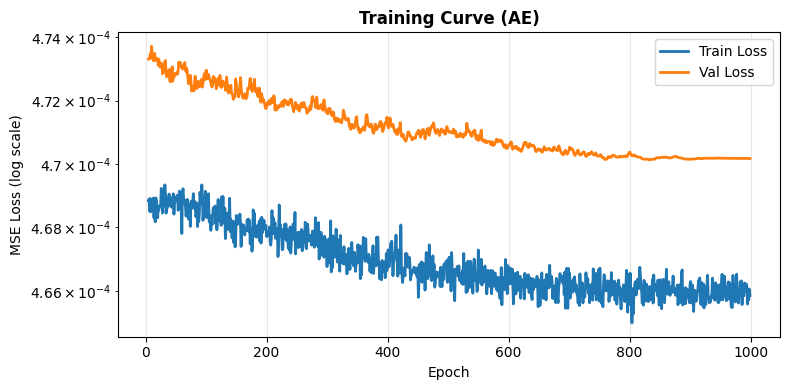

Saved training curve: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE_cholesky\AE_cholesky_12dim_0005_ReLU\loss_curve.png


In [9]:
resume_state_dict = None
resume_initial_val = None
resume_source_path = None
# Resume logic: load checkpoint, check compatibility, extract state dict and initial val loss if available
if RESUME_TRAINING:
    if RESUME_MODEL_PATH is None:
        raise ValueError('RESUME_TRAINING=True but RESUME_MODEL_PATH is None.')

    resume_source_path = Path(RESUME_MODEL_PATH)
    if not resume_source_path.is_absolute():
        if IS_COLAB:
            resume_source_path = Path('/content/drive/MyDrive') / resume_source_path
        else:
            resume_source_path = project_root / resume_source_path
    resume_source_path = resume_source_path.resolve()

    if not resume_source_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {resume_source_path}')

    checkpoint = torch.load(resume_source_path, map_location=device)
    state_dict = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint

    probe_model = AutoEncoder(input_dim=x_train.shape[1], latent_dim=LATENT_DIM, hidden_dims=HIDDEN_DIMS)
    current_shapes = {k: tuple(v.shape) for k, v in probe_model.state_dict().items()}
    loaded_shapes = {k: tuple(v.shape) for k, v in state_dict.items()}

    missing_keys = [k for k in current_shapes.keys() if k not in loaded_shapes]
    shape_mismatches = [
        (k, loaded_shapes[k], current_shapes[k])
        for k in current_shapes.keys()
        if k in loaded_shapes and loaded_shapes[k] != current_shapes[k]
    ]

    if missing_keys or shape_mismatches:
        suggested_hidden = []
        # Cerchiamo tutti i pesi dei layer lineari nell'encoder
        for key, weight in state_dict.items():
            if key.startswith('encoder.') and key.endswith('.weight'):
                # Escludiamo il primo strato (input_dim -> hidden[0])
                # Se il peso ha come input input_dim, è il primo layer, lo saltiamo
                if weight.shape[1] == x_train.shape[1]:
                    continue
                suggested_hidden.append(int(weight.shape[0]))

        # L'ultimo elemento trovato sarà il latent_dim
        if suggested_hidden:
            ckpt_latent_dim = suggested_hidden[-1]
            ckpt_hidden_dims = suggested_hidden[:-1]
            hint = (
                f'Checkpoint expects latent_dim={ckpt_latent_dim}, '
                f'hidden_dims={ckpt_hidden_dims}. '
                'Set these values to match before resuming, or start a new run without resume.'
            )
        else:
            hint = 'Checkpoint architecture could not be inferred. Use a checkpoint saved with the same model architecture.'

        details = []
        if missing_keys:
            details.append(f'Missing keys (first 5): {missing_keys[:5]}')
        if shape_mismatches:
            k, loaded_shape, current_shape = shape_mismatches[0]
            details.append(f'Shape mismatch example: {k} loaded={loaded_shape}, current={current_shape}')

        raise RuntimeError(
            'Incompatible checkpoint for current AutoEncoder architecture. ' + hint + (' | ' + ' ; '.join(details) if details else '')
        )

    resume_state_dict = state_dict
    if isinstance(checkpoint, dict) and 'best_val_loss' in checkpoint:
        resume_initial_val = float(checkpoint['best_val_loss'])

    if resume_initial_val is None:
        temp_model = AutoEncoder(input_dim=x_train.shape[1], latent_dim=LATENT_DIM, hidden_dims=HIDDEN_DIMS).to(device)
        temp_model.load_state_dict(resume_state_dict)
        temp_model.eval()

        val_loader = DataLoader(TensorDataset(x_val), batch_size=BATCH_SIZE, shuffle=False)
        criterion = nn.MSELoss()
        val_loss_sum = 0.0
        with torch.no_grad():
            for (xb,) in val_loader:
                xb = xb.to(device)
                pred = temp_model(xb)
                loss = criterion(pred, xb)
                val_loss_sum += loss.item() * xb.size(0)
        resume_initial_val = val_loss_sum / len(val_loader.dataset)

    print(f'Loaded checkpoint: {resume_source_path}')
    print(f'Checkpoint validation MSE (baseline for resume): {resume_initial_val:.6f}')






# Train the model (or resume training if applicable)
model, history, best_val = train_AE(
    x_train_tensor=x_train,
    x_val_tensor=x_val,
    latent_dim=LATENT_DIM,
    hidden_dims=HIDDEN_DIMS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    dropout=DROPOUT,
    seed=SEED,
    scheduler_name=SCHEDULER_NAME,
    cosine_t_max=COSINE_T_MAX,
    cosine_eta_min=COSINE_ETA_MIN,
    resume_state_dict=resume_state_dict,
    initial_best_val=resume_initial_val,
 )


best_model_path = run_output_dir / 'best_model.pt'
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'model_config': {
            'input_dim': int(x_train.shape[1]),
            'latent_dim': int(LATENT_DIM),
            'hidden_dims': HIDDEN_DIMS,
            'epochs': int(EPOCHS),
            'batch_size': int(BATCH_SIZE),
            'lr': float(LR),
            'weight_decay': float(WEIGHT_DECAY),
            'seed': int(SEED),
            'scheduler': {
                'key': str(SCHEDULER_NAME).strip().lower(),
            },
        },
        'best_val_loss': float(best_val),
    },
    best_model_path,
 )
print(f'Saved best model: {best_model_path}')
print(f'Best validation loss: {best_val:.6f}')


fig, ax = plt.subplots(figsize=(8, 4))
epochs_to_plot = list(range(5, EPOCHS))
ax.plot(epochs_to_plot, history['train_loss'][5:], label='Train Loss', linewidth=2)
ax.plot(epochs_to_plot, history['val_loss'][5:], label='Val Loss', linewidth=2)
ax.set_title('Training Curve (AE)', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_yscale('log')
ax.set_ylabel('MSE Loss (log scale)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

train_curve_path = run_output_dir / 'loss_curve.png'
fig.savefig(train_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved training curve: {train_curve_path}')


In [10]:
print(model)

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=65703, out_features=2048, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.02, inplace=False)
    (3): Linear(in_features=2048, out_features=1024, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.02, inplace=False)
    (6): Linear(in_features=1024, out_features=512, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.02, inplace=False)
    (9): Linear(in_features=512, out_features=12, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.02, inplace=False)
    (3): Linear(in_features=512, out_features=1024, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.02, inplace=False)
    (6): Linear(in_features=1024, out_features=2048, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.02, inplace=False)
    (9): Linear(in_features=2048, out_features=65703, bias=True)
    (10): ReLU()
  )
)


## Step 6: Cholesky Reconstruction Visualization
Visualize original vs reconstructed Cholesky factors ($L$) and optionally the implied correlation matrices $LL^T$.

Original Cholesky (L) top-left 5x5:
[[1.     0.     0.     0.     0.    ]
 [0.3398 0.9405 0.     0.     0.    ]
 [0.3781 0.1727 0.9095 0.     0.    ]
 [0.309  0.4351 0.1168 0.8376 0.    ]
 [0.5604 0.2615 0.1221 0.1252 0.7662]]
Reconstructed L top-left 5x5:
[[0.9975 0.     0.     0.     0.    ]
 [0.3317 0.9407 0.     0.     0.    ]
 [0.3558 0.157  0.918  0.     0.    ]
 [0.301  0.4331 0.1194 0.8401 0.    ]
 [0.546  0.2683 0.1273 0.1112 0.7725]]
Error L top-left 5x5:
[[-0.0025  0.      0.      0.      0.    ]
 [-0.008   0.0002  0.      0.      0.    ]
 [-0.0223 -0.0157  0.0085  0.      0.    ]
 [-0.008  -0.002   0.0026  0.0025  0.    ]
 [-0.0144  0.0068  0.0052 -0.014   0.0063]]
Sample index: 0
L MSE: 0.000203 | L MAE: 0.006561 | L Frobenius: 5.151660
Error range - Min: -0.579403 | Max: 0.205130
Corr MSE: 0.001013 | Corr MAE: 0.023570 | Corr Frobenius: 11.523999
Error range - Min: -0.430905 | Max: 0.328405


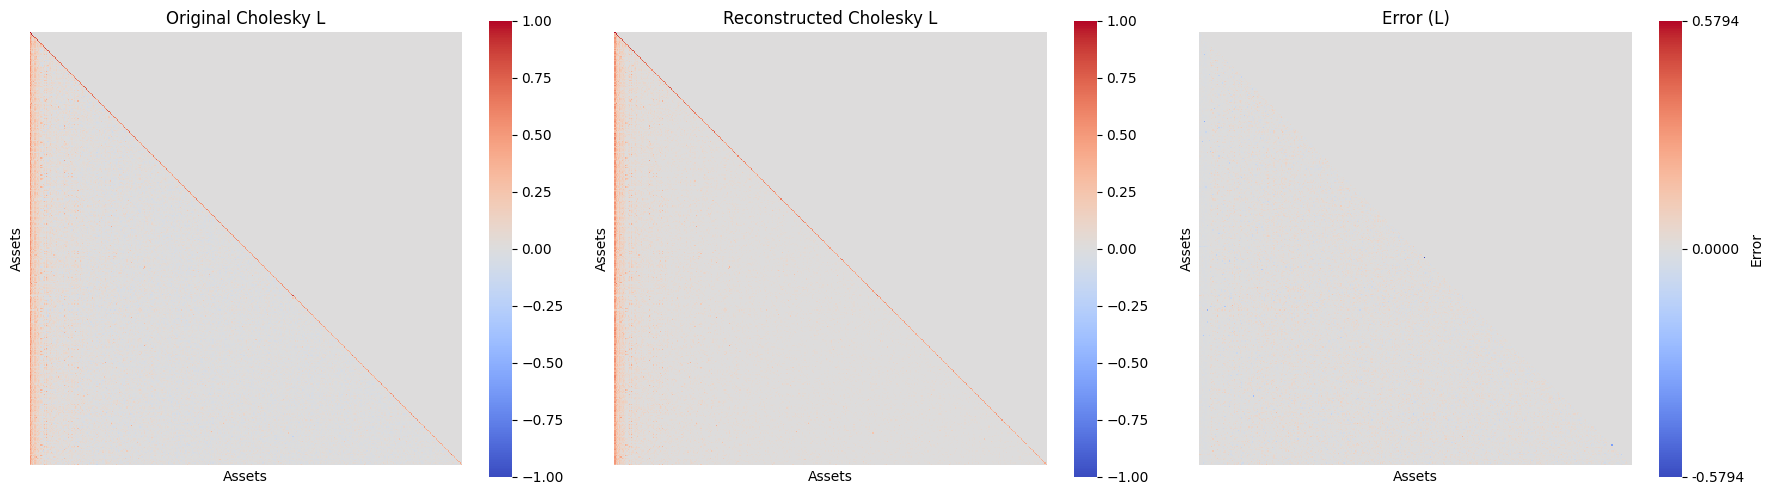

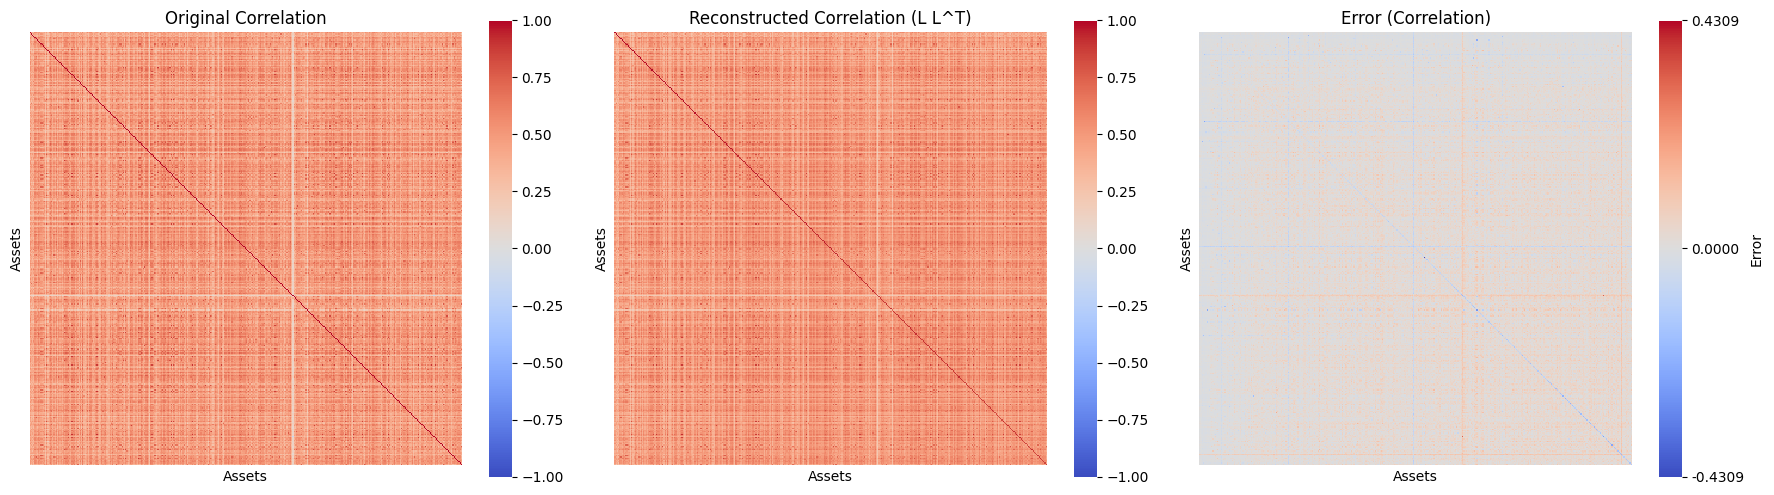

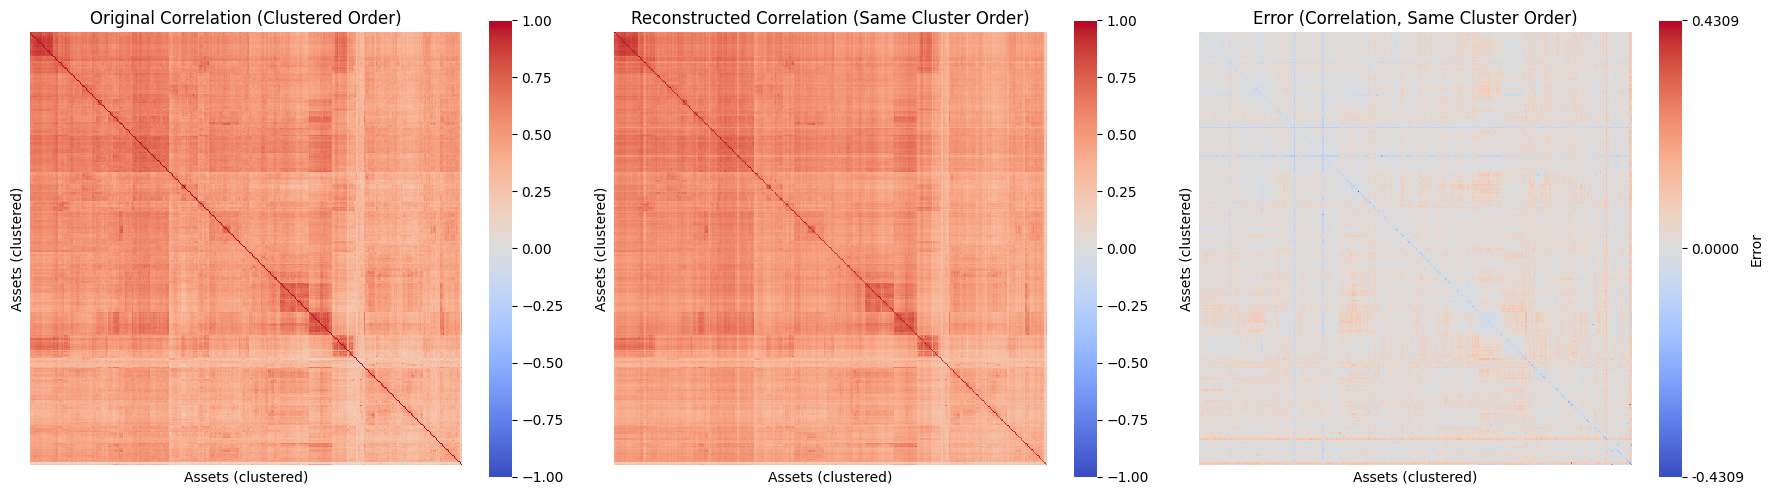

Saved heatmaps for matrix index 0:
 - C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE_cholesky\AE_cholesky_12dim_0005_ReLU\heatmaps\idx0\cholesky_heatmaps.png
 - C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE_cholesky\AE_cholesky_12dim_0005_ReLU\heatmaps\idx0\correlation_heatmaps.png
 - C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE_cholesky\AE_cholesky_12dim_0005_ReLU\heatmaps\idx0\clustered_heatmaps.png


In [11]:
recon_L = reconstruct_cholesky(model, x_test, n_assets=n_assets, tril_idx=tril_idx)

SAMPLE_IDX = 0

if not (0 <= SAMPLE_IDX < test_np.shape[0]):
    raise ValueError(f'SAMPLE_IDX must be in [0, {test_np.shape[0] - 1}]')

orig_L = test_np[SAMPLE_IDX]
recon_L_mat = recon_L[SAMPLE_IDX]
err_L = recon_L_mat - orig_L

orig_corr = test_corr_np[SAMPLE_IDX]
recon_corr = recon_L_mat @ recon_L_mat.T
err_corr = recon_corr - orig_corr

print(f"Original Cholesky (L) top-left 5x5:\n{orig_L[:5, :5]}")
print(f"Reconstructed L top-left 5x5:\n{recon_L_mat[:5, :5]}")
print(f"Error L top-left 5x5:\n{err_L[:5, :5]}")

mse_sample_L = float(np.mean((recon_L_mat - orig_L) ** 2))
mae_sample_L = float(np.mean(np.abs(recon_L_mat - orig_L)))
fro_sample_L = float(np.linalg.norm(recon_L_mat - orig_L, ord='fro'))

mse_sample_corr = float(np.mean((recon_corr - orig_corr) ** 2))
mae_sample_corr = float(np.mean(np.abs(recon_corr - orig_corr)))
fro_sample_corr = float(np.linalg.norm(recon_corr - orig_corr, ord='fro'))

print(f'Sample index: {SAMPLE_IDX}')
print(f'L MSE: {mse_sample_L:.6f} | L MAE: {mae_sample_L:.6f} | L Frobenius: {fro_sample_L:.6f}')
print(f'Error range - Min: {err_L.min():.6f} | Max: {err_L.max():.6f}')
print(f'Corr MSE: {mse_sample_corr:.6f} | Corr MAE: {mae_sample_corr:.6f} | Corr Frobenius: {fro_sample_corr:.6f}')
print(f'Error range - Min: {err_corr.min():.6f} | Max: {err_corr.max():.6f}')

heatmap_base_dir = run_output_dir / 'heatmaps'
heatmap_base_dir.mkdir(parents=True, exist_ok=True)
heatmap_dir = heatmap_base_dir / f'idx{SAMPLE_IDX}'
heatmap_dir.mkdir(parents=True, exist_ok=True)

shared_cmap = 'coolwarm'

# --- Cholesky L heatmaps ---
L_min = -1.0
L_max = 1.0
err_L_abs_max = float(np.max(np.abs(err_L)))
if err_L_abs_max == 0:
    err_L_abs_max = 1e-6

fig_L, axes_L = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_L, ax=axes_L[0], vmin=L_min, vmax=L_max, cmap=shared_cmap, square=True)
axes_L[0].set_title('Original Cholesky L')

sns.heatmap(recon_L_mat, ax=axes_L[1], vmin=L_min, vmax=L_max, cmap=shared_cmap, square=True)
axes_L[1].set_title('Reconstructed Cholesky L')

hm_L = sns.heatmap(
    err_L,
    ax=axes_L[2],
    vmin=-err_L_abs_max,
    vmax=err_L_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_L[2].set_title('Error (L)')

cbar_L = hm_L.collections[0].colorbar
cbar_L.set_ticks([-err_L_abs_max, 0, err_L_abs_max])
cbar_L.set_ticklabels([f'{-err_L_abs_max:.4f}', '0.0000', f'{err_L_abs_max:.4f}'])

for ax in axes_L:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_L = heatmap_dir / 'cholesky_heatmaps.png'
fig_L.savefig(path_L, dpi=150, bbox_inches='tight')
plt.show()

# --- Correlation heatmaps (from L L^T) ---
err_corr_abs_max = float(np.max(np.abs(err_corr)))
if err_corr_abs_max == 0:
    err_corr_abs_max = 1e-6

fig_C, axes_C = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_corr, ax=axes_C[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes_C[0].set_title('Original Correlation')

sns.heatmap(recon_corr, ax=axes_C[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes_C[1].set_title('Reconstructed Correlation (L L^T)')

hm_C = sns.heatmap(
    err_corr,
    ax=axes_C[2],
    vmin=-err_corr_abs_max,
    vmax=err_corr_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_C[2].set_title('Error (Correlation)')

cbar_C = hm_C.collections[0].colorbar
cbar_C.set_ticks([-err_corr_abs_max, 0, err_corr_abs_max])
cbar_C.set_ticklabels([f'{-err_corr_abs_max:.4f}', '0.0000', f'{err_corr_abs_max:.4f}'])

for ax in axes_C:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_C = heatmap_dir / 'correlation_heatmaps.png'
fig_C.savefig(path_C, dpi=150, bbox_inches='tight')
plt.show()

# --- Clustered correlation heatmaps ---
cluster_ref = sns.clustermap(
    orig_corr,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
row_order = cluster_ref.dendrogram_row.reordered_ind
col_order = cluster_ref.dendrogram_col.reordered_ind
plt.close(cluster_ref.fig)

orig_corr_clustered = orig_corr[np.ix_(row_order, col_order)]
recon_corr_clustered = recon_corr[np.ix_(row_order, col_order)]
err_corr_clustered = err_corr[np.ix_(row_order, col_order)]

fig_cluster, axes_cluster = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    orig_corr_clustered,
    ax=axes_cluster[0],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[0].set_title('Original Correlation (Clustered Order)')

sns.heatmap(
    recon_corr_clustered,
    ax=axes_cluster[1],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[1].set_title('Reconstructed Correlation (Same Cluster Order)')

hm_cluster_err = sns.heatmap(
    err_corr_clustered,
    ax=axes_cluster[2],
    vmin=-err_corr_abs_max,
    vmax=err_corr_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_cluster[2].set_title('Error (Correlation, Same Cluster Order)')

cbar_cluster = hm_cluster_err.collections[0].colorbar
cbar_cluster.set_ticks([-err_corr_abs_max, 0, err_corr_abs_max])
cbar_cluster.set_ticklabels([f'{-err_corr_abs_max:.4f}', '0.0000', f'{err_corr_abs_max:.4f}'])

for ax in axes_cluster:
    ax.set_xlabel('Assets (clustered)')
    ax.set_ylabel('Assets (clustered)')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_cluster_corr = heatmap_dir / 'clustered_heatmaps.png'
fig_cluster.savefig(path_cluster_corr, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved heatmaps for matrix index {SAMPLE_IDX}:')
print(f' - {path_L}')
print(f' - {path_C}')
print(f' - {path_cluster_corr}')

## Step 7: Reconstruction Error Statistics
Compute error statistics on the test set for Cholesky factors ($L$) and optionally for the implied correlations $LL^T$.

In [12]:
# Compute error statistics on test set (Cholesky L)
recon_L_test = recon_L

errors_df, errors_stats = reconstruction_errors(test_np, recon_L_test)

# Optional: error statistics on implied correlation matrices
recon_corr_test = cholesky_to_corr(recon_L_test)
corr_errors_df, corr_errors_stats = reconstruction_errors(test_corr_np, recon_corr_test)

print('Reconstruction error statistics (Cholesky L - Test Set):')
display(errors_stats)

print('Reconstruction error statistics (Correlation - Test Set):')
display(corr_errors_stats)

Reconstruction error statistics (Cholesky L - Test Set):


,mean,std,min,median,max
MSE,0.000230,0.000028,0.000181,0.000232,0.000288
MAE,0.007246,0.000561,0.006334,0.007233,0.008319
Frobenius,5.481676,0.337157,4.872441,5.518887,6.143193


Reconstruction error statistics (Correlation - Test Set):


,mean,std,min,median,max
MSE,0.001423,0.000711,0.000535,0.001178,0.003228
MAE,0.026872,0.006527,0.016955,0.025403,0.041817
Frobenius,13.268648,3.263891,8.373347,12.425094,20.565962


In [13]:
results_path = run_output_dir / 'run_results.json'

recon_stats_payload = None
if 'errors_stats' in globals():
    recon_stats_payload = errors_stats.astype(float).to_dict()

corr_stats_payload = None
if 'corr_errors_stats' in globals():
    corr_stats_payload = corr_errors_stats.astype(float).to_dict()

scheduler_key = str(SCHEDULER_NAME).strip().lower()

if scheduler_key == 'none':
    scheduler_payload = None
elif scheduler_key == 'cosine':
    scheduler_payload = {
        'key': scheduler_key,
        'T_max': int(COSINE_T_MAX),
        'eta_min': float(COSINE_ETA_MIN),
    }

resumed = bool(RESUME_TRAINING)
if resumed:
    resume_info = {
        'source_model_path': str(resume_source_path) if resume_source_path is not None else None,
        'initial_best_val': float(resume_initial_val) if resume_initial_val is not None else None,
    }
else:
    resume_info = None

if MODEL_TYPE == 'linearAE_cholesky':
    dropout_info = None
    hidden_dims_info = None
elif MODEL_TYPE == "AE_cholesky":
    dropout_info = float(DROPOUT)
    hidden_dims_info = [int(x) for x in HIDDEN_DIMS]

results_payload = {
    'run': RUN,
    'seed': int(SEED),
    'dataset_info': {
        'dataset_name': DATASET_NAME,
        'representation': 'cholesky_lower_triangular',
        'n_matrices': int(n_matrices),
        'n_assets': int(n_assets),
        'n_features': int(n_features),
        'splits': {
            'train_size': int(n_train),
            'val_size': int(n_val),
            'test_size': int(n_test),
            'val_fraction': round(float(VAL_FRACTION), 2),
            'test_fraction': round(float(TEST_FRACTION), 2),
        },
    },
    'model': {
        'model_type': MODEL_TYPE,
        'latent_dim': int(LATENT_DIM),
        'hidden_dims': hidden_dims_info,
        'epochs': int(EPOCHS),
        'batch_size': int(BATCH_SIZE),
        'lr': float(LR),
        'weight_decay': float(WEIGHT_DECAY),
        'dropout': dropout_info,
        'scheduler': scheduler_payload,
        'best_val_loss': float(best_val) if 'best_val' in globals() else None,
        'resume': resume_info,
    },
    'artifacts': {
        'best_model_path': str(best_model_path) if 'best_model_path' in globals() else None,
        'training_curve_path': str(train_curve_path) if 'train_curve_path' in globals() else None,
    },
    'metrics': {
        'reconstruction_stats_on_test_set_L': recon_stats_payload,
        'reconstruction_stats_on_test_set_corr': corr_stats_payload,
    },
    'loss_history': {
        'train_loss': [float(x) for x in history['train_loss']],
        'val_loss': [float(x) for x in history['val_loss']],
        'lr': [float(x) for x in history['lr']] if 'lr' in history else None,
    },
}

with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results_payload, f, indent=4)

print(f'Saved results: {results_path}')

Saved results: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE_cholesky\AE_cholesky_12dim_0005_ReLU\run_results.json
